# 2. Решающий слой: от вероятностей к выезду бригады

Сеть выдаёт `P(необходимость ТО | показания)`. Но решение «ехать или нет» —
это вероятность **плюс цена ошибки**. Правило Табл. 3.5 диплома
(`действие = наиболее вероятное состояние`) неявно предполагает, что
пропустить аварию так же плохо, как съездить зря.

Между тем весь эффект пилота — ложные выезды 6–8 в месяц → 1–2 при том, что
пропущенных отказов стало не больше — это история именно про асимметрию цен
ошибок, а не про точность классификации.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.model import BayesNet
from src.network_spec import STATES
from src.decision import (ACTIONS, ACTION_LABEL, NEED, Costs, breakeven_ratio,
                          capacity_sweep, compare_policies, cost_ratio_sweep,
                          evaluate, explain_decision, policy_actions,
                          posterior_lookup, triage)

pd.set_option("display.width", 160)
net = BayesNet.from_spec()

## 2.1 Матрица потерь

За единицу принята стоимость срочного выезда. Ключевой параметр —
`miss_to_visit` (обозначим `R`): во сколько раз пропущенный отказ дороже
выезда. Это единственная величина, которую предприятию действительно нужно
оценить, и она управленческая, а не статистическая.

In [2]:
costs = Costs()
L = pd.DataFrame(costs.matrix(),
                 index=[ACTION_LABEL[a] for a in ACTIONS],
                 columns=[f"нужно: {s}" for s in STATES[NEED]])
print(f"Параметры: R = {costs.miss_to_visit}, плановый выезд = {costs.planned_visit}, "
      f"доля ущерба при опоздании = {costs.late_fraction}\n")
print(L.round(2).to_string())

Параметры: R = 5.0, плановый выезд = 0.4, доля ущерба при опоздании = 0.5

                                    нужно: не_требуется  нужно: плановое  нужно: срочное
Плановый режим наблюдения                           0.0              1.5             5.0
Включение объекта в план ТО                         0.4              0.4             2.9
Немедленная диспетчеризация выезда                  1.0              1.0             1.0


## 2.2 Разбор одного решения

Сценарий 1 Табл. 3.6: давление отклонилось, расход аномально высокий,
прибору 3–7 лет, поверка скоро истекает.

In [3]:
ev = dict(pressure="otklonenie", temperature="norma", flow="anomal_high",
          calibration="priblizhaetsya", age="3_7")
belief = net.posterior(ev, [NEED])[NEED]
print("Апостериорное распределение необходимости ТО:")
for s, p in zip(STATES[NEED], belief):
    print(f"  {s:14s} {p:.3f}")
print()
print(explain_decision(net, ev, costs).to_string(index=False))

Апостериорное распределение необходимости ТО:
  не_требуется   0.128
  плановое       0.324
  срочное        0.548

                          действие  ожидаемые_потери       выбор
         Плановый режим наблюдения             3.225            
       Включение объекта в план ТО             1.769            
Немедленная диспетчеризация выезда             1.000 <-- минимум


Обратите внимание: наиболее вероятное состояние — «не требуется», и правило
Табл. 3.5 велело бы остаться в режиме наблюдения. Байесовское решение при
R = 5 отправляет бригаду, потому что 13-процентный шанс аварии, умноженный
на её цену, перевешивает гарантированную стоимость выезда.

## 2.3 Порога нет — есть цена ошибки

«При какой вероятности ехать?» — вопрос поставлен неверно. Правильный:
«насколько дорога авария по сравнению с выездом?». Ответ для этого объекта:

In [4]:
switch = breakeven_ratio(net, ev, costs)
bounds = list(switch.items()) + [(None, None)]
for (a, lo), (_, hi) in zip(bounds[:-1], bounds[1:]):
    rng = f"R < {hi:.1f}" if hi is not None else f"R ≥ {lo:.1f}"
    print(f"  {rng:12s} →  {ACTION_LABEL[a]}")

  R < 2.2      →  Включение объекта в план ТО
  R ≥ 2.2      →  Немедленная диспетчеризация выезда


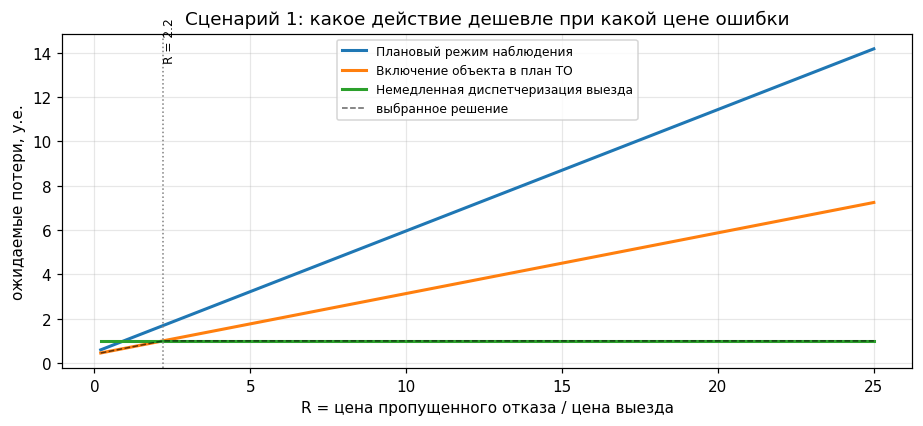

In [5]:
grid = np.linspace(0.2, 25, 220)
curves = np.stack([costs.__class__(miss_to_visit=float(r)).matrix() @ belief for r in grid])
fig, ax = plt.subplots(figsize=(8.5, 4))
for i, a in enumerate(ACTIONS):
    ax.plot(grid, curves[:, i], lw=2, label=ACTION_LABEL[a])
ax.plot(grid, curves.min(axis=1), "k--", lw=1, alpha=.6, label="выбранное решение")
for r in switch.values():
    if r > 0:
        ax.axvline(r, color="gray", ls=":", lw=1)
        ax.annotate(f"R = {r:.1f}", (r, ax.get_ylim()[1] * 0.92), fontsize=8, rotation=90)
ax.set_xlabel("R = цена пропущенного отказа / цена выезда")
ax.set_ylabel("ожидаемые потери, у.е.")
ax.set_title("Сценарий 1: какое действие дешевле при какой цене ошибки")
ax.legend(fontsize=8)
ax.grid(alpha=.3)
fig.tight_layout()
plt.show()

## 2.4 Сравнение стратегий на синтетическом парке

Нормировка «на 100 объектов» здесь почти буквальная: в отопительный сезон
парк предприятия — около 120 объектов. Три стратегии:

* **реактивная** — выезд по превышению порога расхода (то, что было «до»);
* **argmax** — правило Табл. 3.5 в лоб;
* **байесовская** — минимум ожидаемых потерь.

In [6]:
print(compare_policies(net=net, costs=costs).round(3).to_string(index=False))

                         стратегия  выездов  срочных_выездов  ложных_срочных  пропущено_срочных  средние_потери
Реактивное правило (порог расхода)    9.775            9.775           3.085             12.020           0.981
          БСД + argmax (Табл. 3.5)    8.940            8.940           2.250             11.935           0.970
     БСД + мин. ожид. потерь (R=5)   88.875           22.335           7.995              0.690           0.732


Средняя строка — самая интересная. Правило Табл. 3.5 экономит выезды
(2.3 ложных против 3.1), но пропускает практически столько же срочных
случаев, что и грубый порог по расходу. Оно покупает экономию пропусками, и
без матрицы потерь это не видно ни в accuracy, ни в F1.

**Но у этой таблицы есть методологический изъян, и его надо назвать.**
Данные порождены той же сетью, по которой считаются апостериорные, поэтому
байесовская стратегия оптимальна **по построению**: её победа здесь ничего
не доказывает. Это ровно тот дефект, из-за которого в ноутбуке 4 появились
два режима сравнения с ML.

Честная проверка — прогнать те же стратегии против **возмущённой** сети:
структура у политики верная, числа в CPT — нет. Ровно положение реальной
экспертной модели.

In [7]:
misspec = net.perturb(np.random.default_rng(7), 0.5)
print(compare_policies(net=net, costs=costs, gen_net=misspec)
      .round(3).to_string(index=False))

                         стратегия  выездов  срочных_выездов  ложных_срочных  пропущено_срочных  средние_потери
Реактивное правило (порог расхода)    7.400            7.400           2.655             18.370           1.245
          БСД + argmax (Табл. 3.5)    7.325            7.325           2.095             18.235           1.232
     БСД + мин. ожид. потерь (R=5)   92.320           16.035           6.075              1.060           0.902


Вывод устоял: байесовская стратегия остаётся лучшей по средним потерям и
на данных, устройство которых она угадывает неверно. Абсолютные уровни
ухудшились у всех трёх стратегий — это и должно происходить, когда модель
ошибается в вероятностях, — но порядок между ними сохранился.

## 2.5 Компромисс, которым управляет цена ошибки

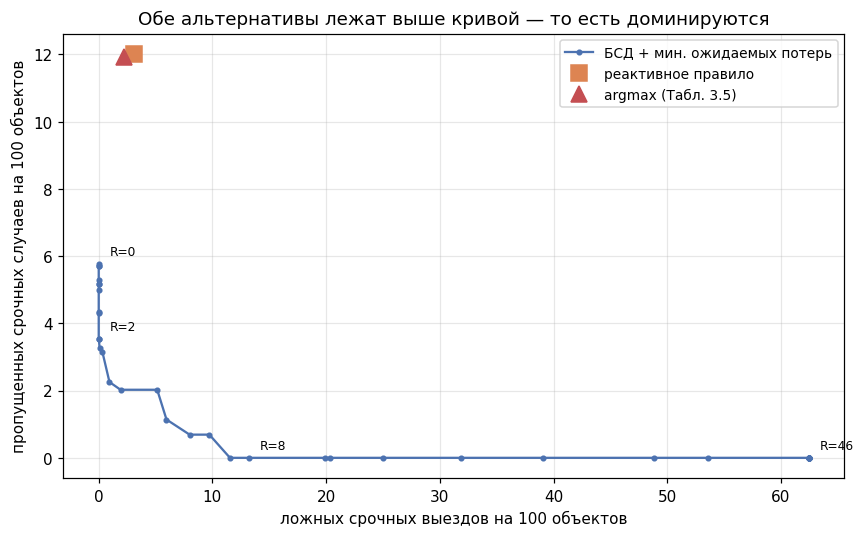

In [8]:
df = net.sample(20000, np.random.default_rng(42))
lookup = posterior_lookup(net)
ratios = np.geomspace(0.5, 60, 36)
fp, miss = [], []
for r in ratios:
    c = Costs(miss_to_visit=float(r))
    m = evaluate(df, policy_actions(df, "bayes", net, c, lookup), c)
    fp.append(m["ложных_срочных"]); miss.append(m["пропущено_срочных"])

pts = {}
for name, label in [("reactive", "реактивное правило"), ("map", "argmax (Табл. 3.5)")]:
    m = evaluate(df, policy_actions(df, name, net, costs, lookup), costs)
    pts[label] = (m["ложных_срочных"], m["пропущено_срочных"])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(fp, miss, "-o", ms=3, color="#4c72b0", label="БСД + мин. ожидаемых потерь")
for i in (0, 10, 20, 33):
    ax.annotate(f"R={ratios[i]:.0f}", (fp[i], miss[i]), textcoords="offset points",
                xytext=(7, 6), fontsize=8)
for (label, (x, y)), mk, col in zip(pts.items(), ["s", "^"], ["#dd8452", "#c44e52"]):
    ax.plot(x, y, mk, ms=11, color=col, label=label)
ax.set_xlabel("ложных срочных выездов на 100 объектов")
ax.set_ylabel("пропущенных срочных случаев на 100 объектов")
ax.set_title("Обе альтернативы лежат выше кривой — то есть доминируются")
ax.legend(fontsize=9)
ax.grid(alpha=.3)
fig.tight_layout()
plt.show()

## 2.6 Одна бригада: задача не «ехать или нет», а «к кому первым»

У микропредприятия бригада одна, поэтому «выехать на всё, что выгодно»
физически недостижимо. Реальная задача диспетчера — ранжирование. Ценность
выезда на объект = снижение ожидаемых потерь относительно бездействия.

Ниже один и тот же бюджет выездов распределяется двумя способами:
по срабатыванию порога расхода и по ожидаемой выгоде.

In [9]:
sweep = capacity_sweep(net=net, costs=costs)
print(sweep.round(3).to_string(index=False))

 лимит_выездов_на_100  пропущено_срочных__реактивно  пропущено_срочных__БСД  потери__реактивно  потери__БСД
                    2                        14.935                  14.680              1.086        1.072
                    5                        13.750                  13.395              1.042        1.023
                   10                        12.020                  11.585              0.981        0.958
                   20                        12.020                   8.665              0.981        0.869
                   40                        12.020                   5.140              0.981        0.786
                   80                        12.020                   1.315              0.981        0.735


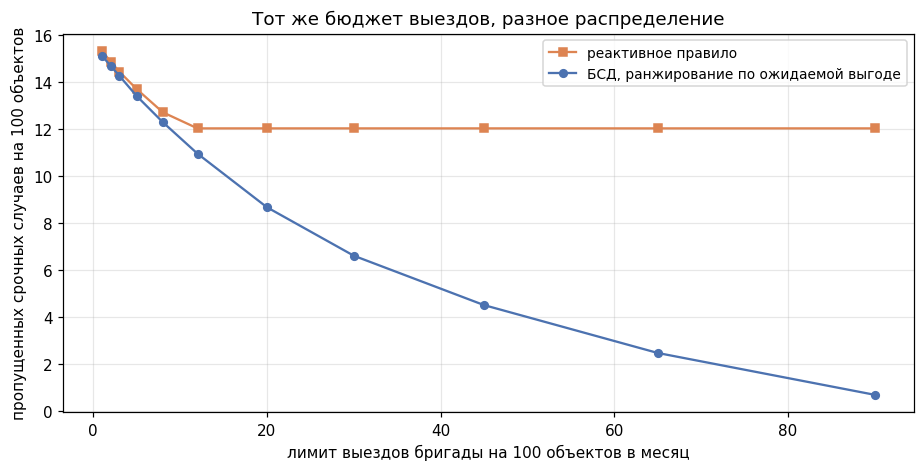

In [10]:
caps = [1, 2, 3, 5, 8, 12, 20, 30, 45, 65, 90]
s = capacity_sweep(caps, net=net, costs=costs)
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.plot(s["лимит_выездов_на_100"], s["пропущено_срочных__реактивно"], "-s", ms=5,
        color="#dd8452", label="реактивное правило")
ax.plot(s["лимит_выездов_на_100"], s["пропущено_срочных__БСД"], "-o", ms=5,
        color="#4c72b0", label="БСД, ранжирование по ожидаемой выгоде")
ax.set_xlabel("лимит выездов бригады на 100 объектов в месяц")
ax.set_ylabel("пропущенных срочных случаев на 100 объектов")
ax.set_title("Тот же бюджет выездов, разное распределение")
ax.legend(fontsize=9)
ax.grid(alpha=.3)
fig.tight_layout()
plt.show()

Реактивное правило упирается в потолок: оно видит только объекты, где
сработал порог расхода, и дополнительный бюджет ему некуда девать.
Ранжирование по ожидаемой выгоде продолжает снижать пропуски.

**Оговорка о базовой частоте.** В синтетическом парке `P(срочное) ≈ 13 %`,
потому что априорные вероятности входов — допущение для симуляции, а не
измеренные частоты. На пилоте доля «тяжёлых» объектов была ниже, поэтому
абсолютные уровни здесь завышены; сравнение стратегий между собой корректно,
так как все они работают на одной базе. Числа станут сопоставимы с пилотом
напрямую, как только `PRIOR` будет заменён частотами из выгрузки АИС.